# Tech Sector Portfolio Analysis

End-to-end quantitative analysis of **35 stocks** across **AI, Semiconductor, and New Energy** sectors — from raw data through EDA, volatility, correlation, lead-lag, risk assessment, mean-variance portfolio optimization, and backtesting.

> Data period: May 2025 – May 2026 (251 trading days)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import display, Image
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

DATA = Path("data")
CHART = Path("charts")

## Key Results

| Portfolio Strategy | Total Return | Sharpe Ratio | Max Drawdown | Win Rate |
|---|:---:|:---:|:---:|:---:|
| **Max Sharpe** | **+364.8%** | **4.46** | -13.6% | 63.6% |
| Sector Equal Weight | +80.9% | 2.15 | -14.5% | 56.0% |
| Equal Weight | +75.6% | 2.03 | -15.1% | 56.4% |
| S&P 500 (Benchmark) | +26.8% | 1.63 | -9.1% | 57.2% |

> The optimized Max Sharpe portfolio delivered **13.6x** the S&P 500 return over the analysis period, driven by concentrated allocation to top Chip-sector names (INTC, MU, GOOGL each at the 15% cap).

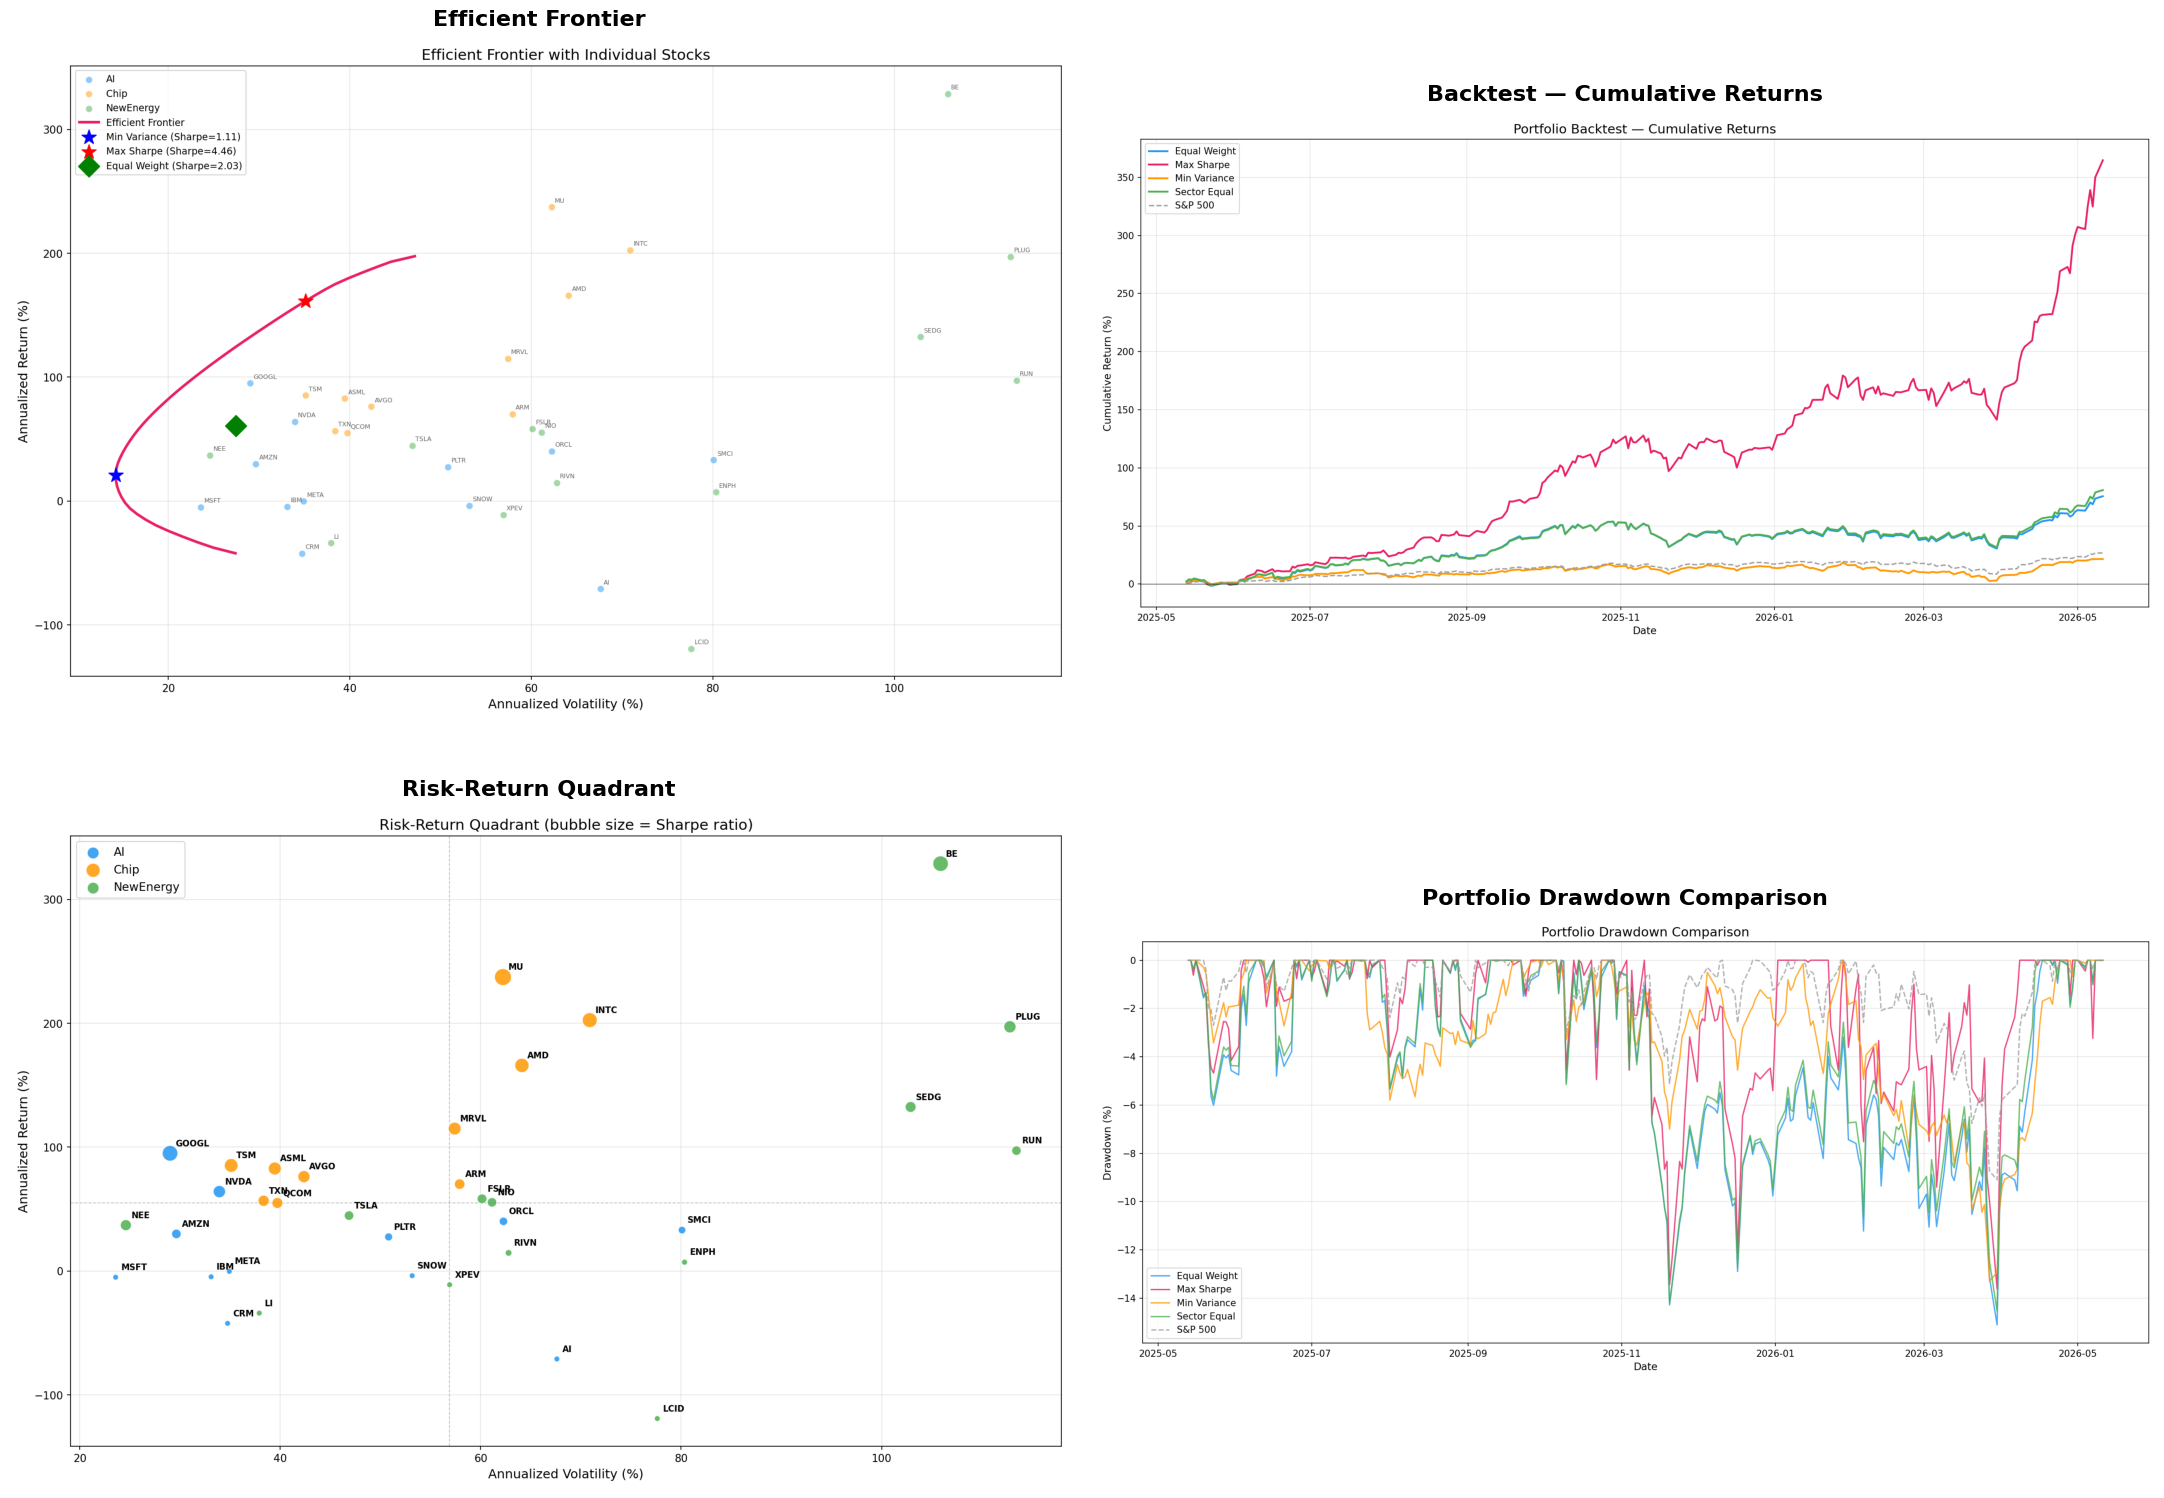

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(22, 16))
charts = [
    (CHART / "Part6_Portfolio/Step12_EfficientFrontier/efficient_frontier.png", "Efficient Frontier"),
    (CHART / "Part6_Portfolio/Step13_Backtest/cumulative_returns.png", "Backtest — Cumulative Returns"),
    (CHART / "Part5_Risk/Step11_RiskMetrics/risk_return_quadrant.png", "Risk-Return Quadrant"),
    (CHART / "Part6_Portfolio/Step13_Backtest/drawdown_comparison.png", "Portfolio Drawdown Comparison"),
]
for ax, (path, title) in zip(axes.flat, charts):
    ax.imshow(mpimg.imread(str(path)))
    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)
    ax.axis("off")
plt.tight_layout(pad=2)
plt.show()

---
## Analysis Pipeline

```
Data ── Part 1: EDA ── Part 2: Volatility ── Part 3: Correlation ── Part 4: Lead-Lag
                                                                       │
                        Part 6: Portfolio ◄── Part 5: Risk ◄───────────┘
```

| Part | Script | Steps | Description |
|---|---|:---:|---|
| Data | `download_data.py` | 1 | Download 1-year daily OHLCV from Yahoo Finance |
| Part 1: EDA | `EDA.py` `candlestick.py` `returns.py` | 2–3 | Data quality, line charts, return distributions |
| Part 2: Volatility | `volatility.py` | 4–5 | Annualized volatility, rolling volatility, anomaly detection |
| Part 3: Correlation | `correlation.py` | 6–7 | Cross-sector correlation, Beta analysis |
| Part 4: Lead-Lag | `leadlag.py` | 8–9 | Lagged correlation, leadership scores |
| Part 5: Risk | `risk.py` | 10–11 | Drawdowns, VaR, Sharpe / Sortino / Calmar |
| Part 6: Portfolio | `portfolio.py` | 12–13 | Efficient frontier, portfolio backtesting |

## Stock Universe

In [3]:
summary = pd.read_csv(DATA / "_summary.csv")
overview = summary.groupby("Sector").agg(
    Count=("Ticker", "count"),
    Tickers=("Ticker", lambda x: ", ".join(x)),
)
display(overview)
print(f"\nData period: {summary['Start'].iloc[0]} ~ {summary['End'].iloc[0]}  |  {summary['Records'].iloc[0]} trading days per stock")

,Count,Tickers
Sector,,
AI,12,"NVDA, MSFT, GOOGL, META, AMZN, CRM, PLTR, AI, ..."
Chip,10,"AMD, INTC, TSM, AVGO, QCOM, TXN, MU, MRVL, ARM..."
Index,6,"^GSPC, ^IXIC, ^DJI, ^RUT, ^VIX, ^SOX"
NewEnergy,13,"TSLA, ENPH, SEDG, FSLR, RUN, PLUG, BE, NEE, RI..."



Data period: 2025-05-12 ~ 2026-05-11  |  251 trading days per stock


---
## Part 1: Exploratory Data Analysis

### Step 1 — Data Quality Check

All 9 quality checks passed. Minor Yahoo data precision issues (NEE and XPEV each had 1 day where Open slightly exceeded High). VIX and SOX show zero volume throughout (normal for indices).

### Step 2 — Performance Ranking & Sector Comparison

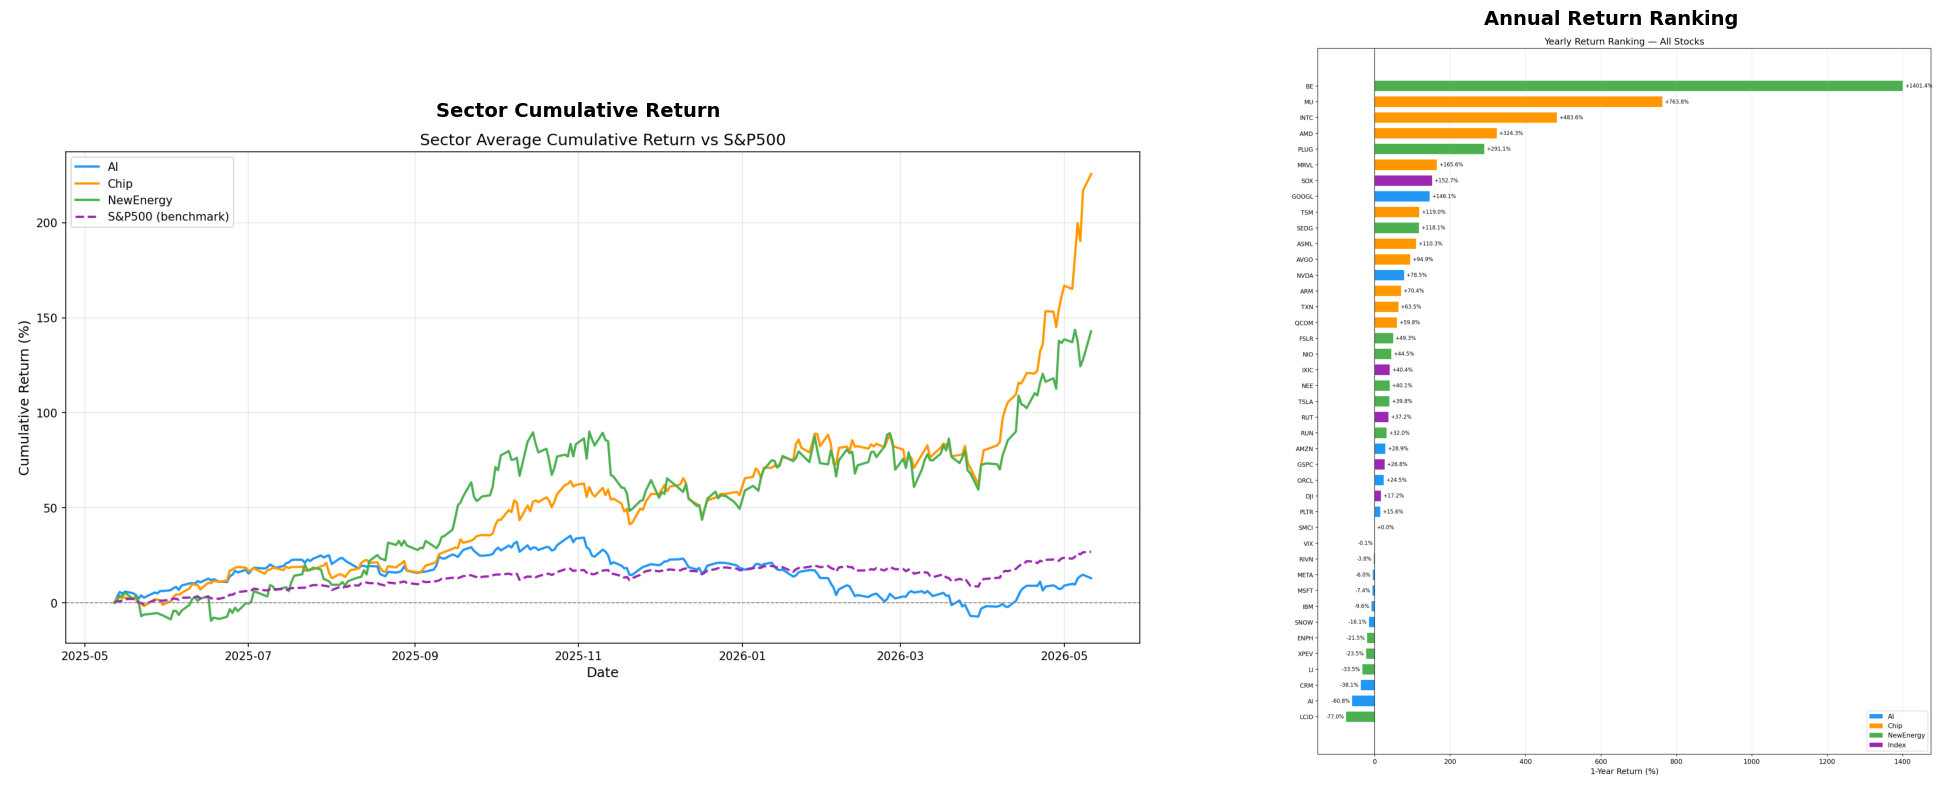

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
ax1.imshow(mpimg.imread(str(CHART / "Part1_EDA/Step2_LineCharts/sector_cumulative_return.png")))
ax1.set_title("Sector Cumulative Return", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part1_EDA/Step3_Returns/yearly_return_ranking.png")))
ax2.set_title("Annual Return Ranking", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

In [5]:
perf = pd.read_csv(CHART / "Part1_EDA/Step2_LineCharts/performance_summary.csv")

print("\u2501" * 60)
print("Top 10 Gainers")
print("\u2501" * 60)
display(perf.nlargest(10, "Return%")[["Ticker", "Name", "Sector", "Return%", "Annual_Vol%", "Sharpe", "Max_Drawdown%"]])

print("\n" + "\u2501" * 60)
print("Top 5 Losers")
print("\u2501" * 60)
display(perf.nsmallest(5, "Return%")[["Ticker", "Name", "Sector", "Return%", "Annual_Vol%", "Sharpe", "Max_Drawdown%"]])

print("\n" + "\u2501" * 60)
print("Sector Average Performance")
print("\u2501" * 60)
sector_avg = perf.groupby("Sector").agg({"Return%": "mean", "Annual_Vol%": "mean", "Sharpe": "mean", "Max_Drawdown%": "mean"}).round(2)
display(sector_avg.sort_values("Return%", ascending=False))

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Top 10 Gainers
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Ticker,Name,Sector,Return%,Annual_Vol%,Sharpe,Max_Drawdown%
28,BE,Bloom Energy,NewEnergy,1401.43,105.89,3.11,-45.94
18,MU,Micron,Chip,763.83,62.22,3.81,-30.28
13,INTC,Intel,Chip,483.59,70.88,2.86,-24.17
12,AMD,AMD,Chip,324.33,64.11,2.59,-27.76
27,PLUG,Plug Power,NewEnergy,291.11,112.81,1.75,-56.66
19,MRVL,Marvell,Chip,165.57,57.40,2.00,-26.37
40,^SOX,PHLX_Semiconductor,Index,152.69,32.72,3.02,-15.65
2,GOOGL,Google,AI,146.11,29.00,3.28,-20.37
14,TSM,TSMC,Chip,119.04,35.10,2.43,-18.14
24,SEDG,SolarEdge,NewEnergy,118.11,102.90,1.29,-37.26



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Top 5 Losers
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Ticker,Name,Sector,Return%,Annual_Vol%,Sharpe,Max_Drawdown%
31,LCID,Lucid,NewEnergy,-76.98,77.62,-1.53,-81.60
7,AI,C3.ai,AI,-60.83,67.60,-1.05,-73.39
5,CRM,Salesforce,AI,-38.09,34.74,-1.22,-42.92
33,LI,Li Auto,NewEnergy,-33.51,37.90,-0.90,-50.53
34,XPEV,XPeng,NewEnergy,-23.53,56.90,-0.19,-44.60



━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Sector Average Performance
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


,Return%,Annual_Vol%,Sharpe,Max_Drawdown%
Sector,,,,
Chip,225.53,50.75,2.17,-27.74
NewEnergy,142.86,72.56,0.70,-44.47
Index,45.72,35.16,1.82,-18.03
AI,12.95,44.40,0.42,-41.12


**Key findings:**
- **Chip sector dominates:** Average return +225.5%, Sharpe ratio 2.17
- **AI software lags infrastructure:** AI sector averaged only +13.0%, below the S&P 500's +26.8%
- **BE (Bloom Energy) surged 14x** over the year, from \$18.91 to \$283.92

### Step 3 — Monthly Return Heatmap

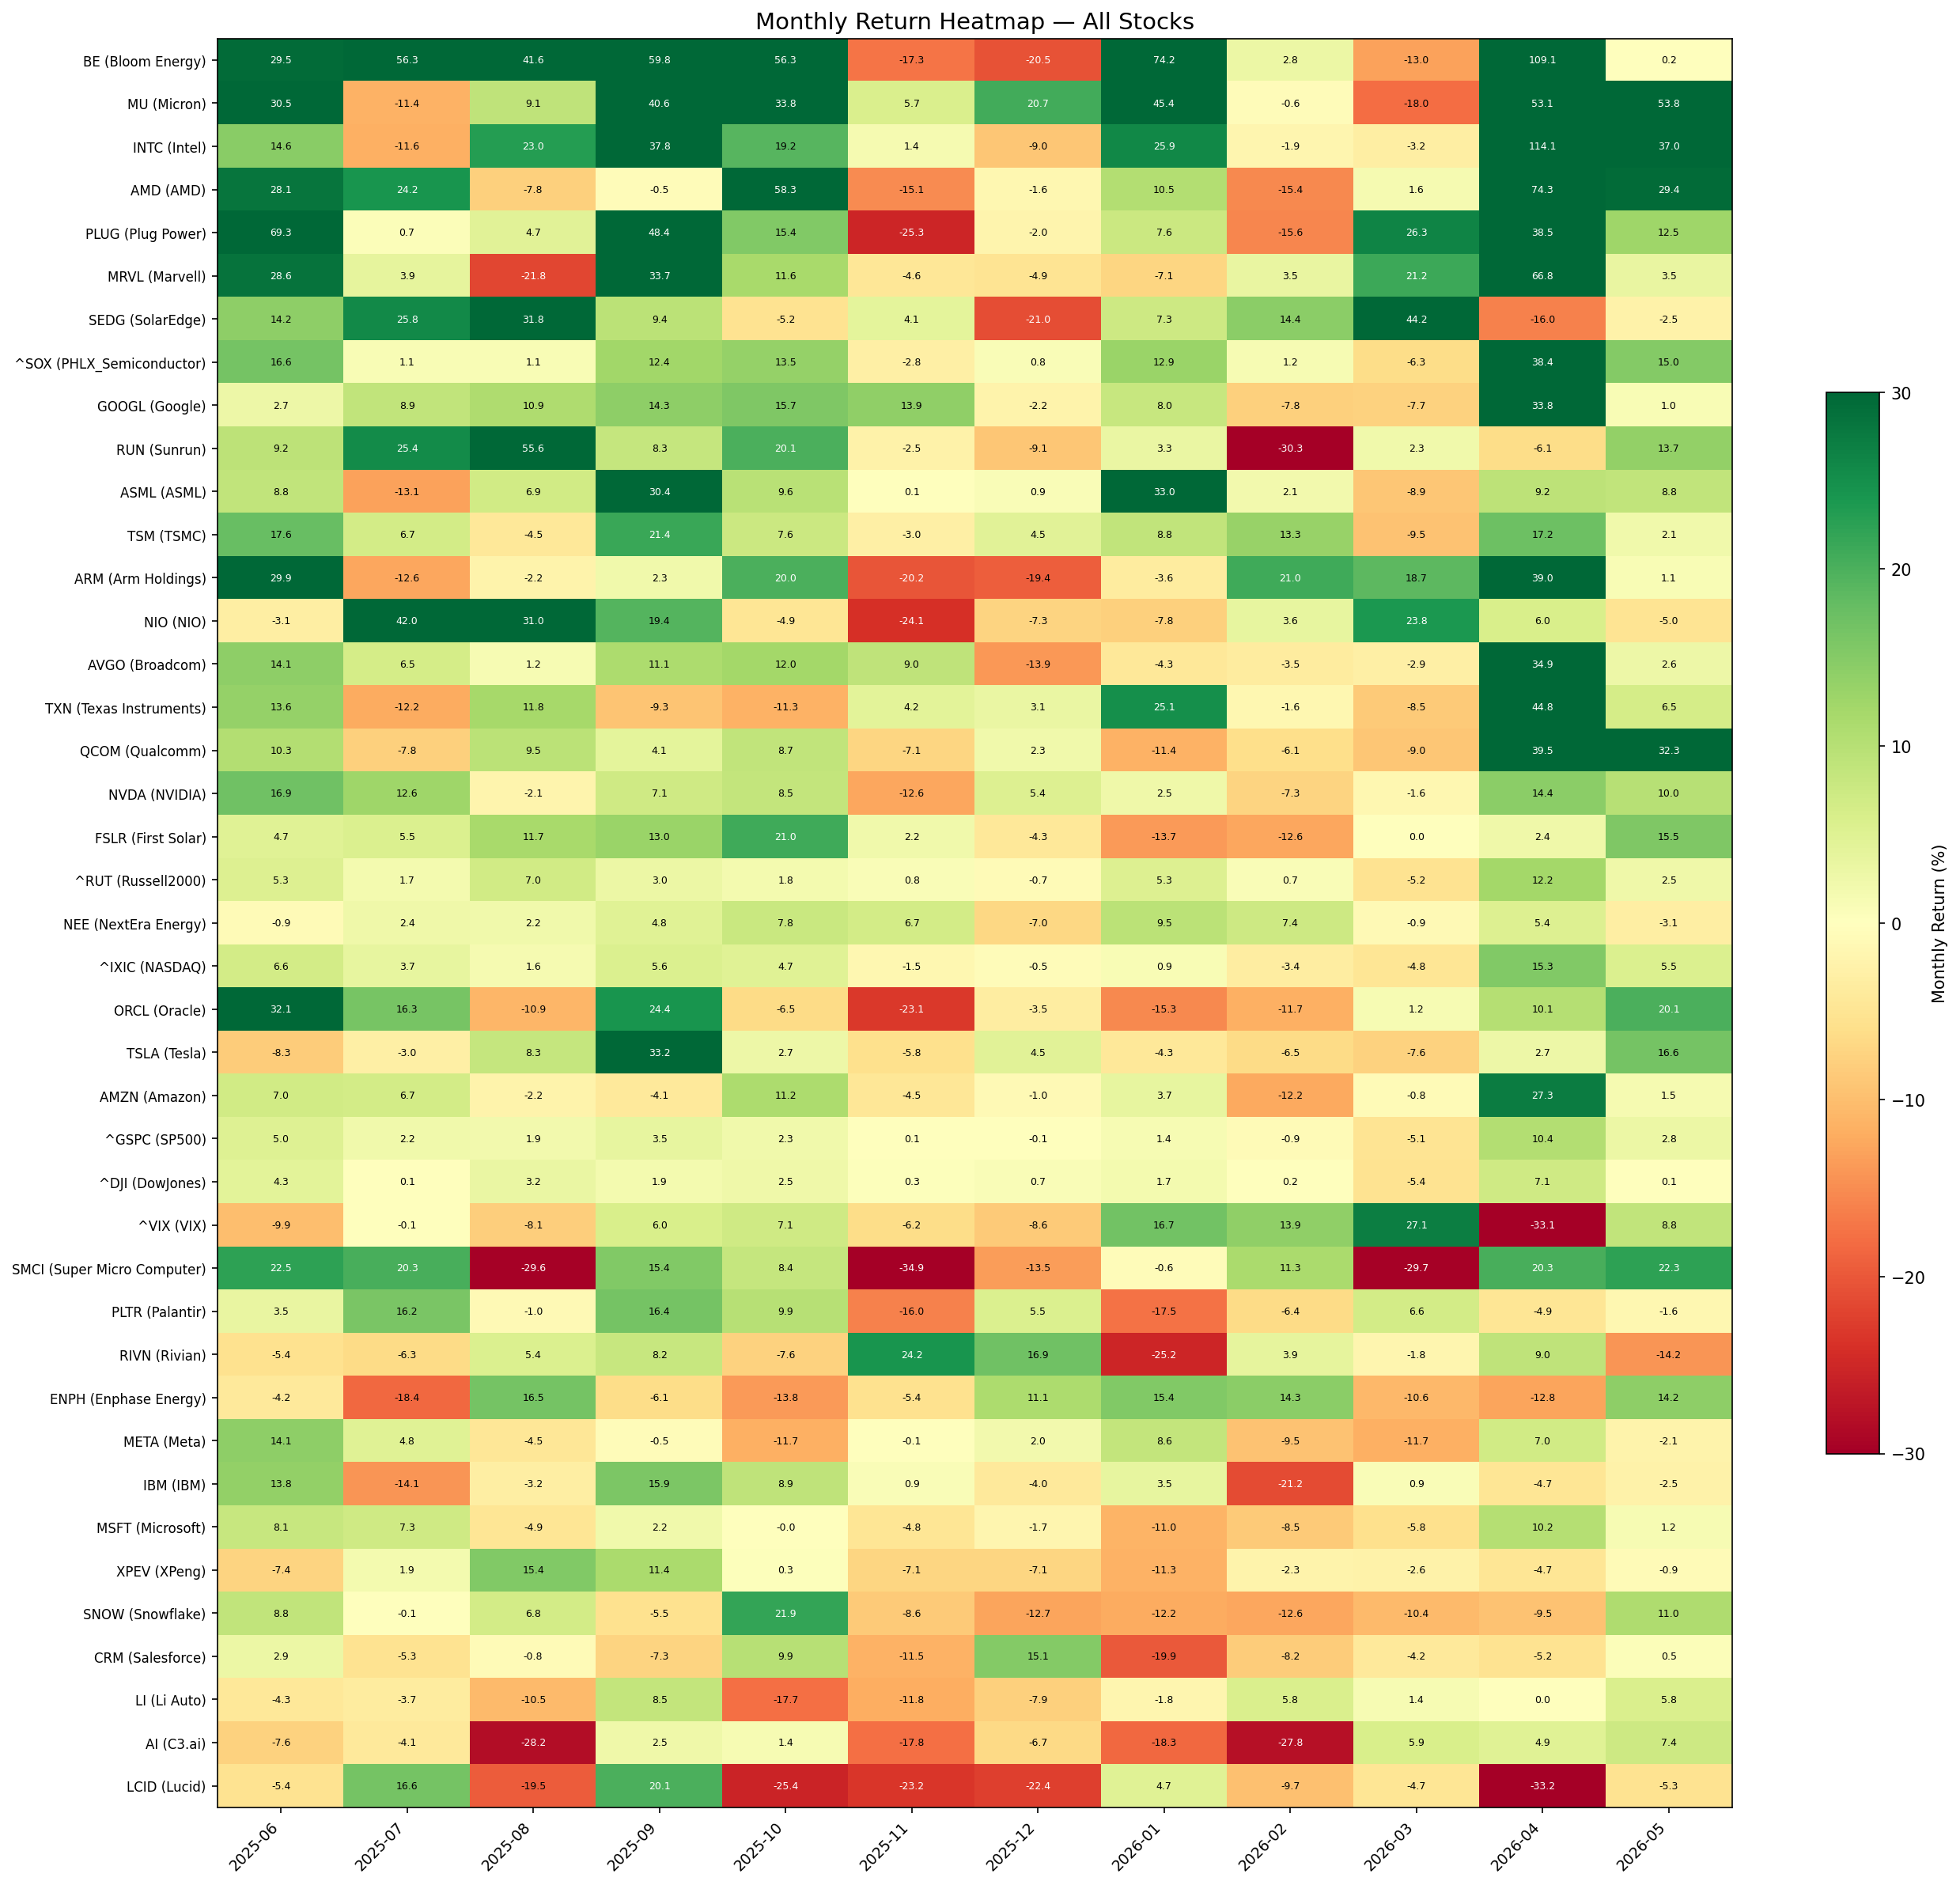

In [6]:
display(Image(str(CHART / "Part1_EDA/Step3_Returns/monthly_return_heatmap.png"), width=900))

---
## Part 2: Volatility Analysis

### Cross-Sector Correlation Decision

Average pairwise correlation at the individual stock level: AI vs Chip = 0.21, AI vs NewEnergy = 0.12, Chip vs NewEnergy = 0.18.

**Decision:** NewEnergy was excluded from the volatility comparison due to correlation below the 0.3 threshold. AI and Chip show significantly stronger co-movement.

### Step 4 — Annualized Volatility & Step 5 — Rolling Volatility

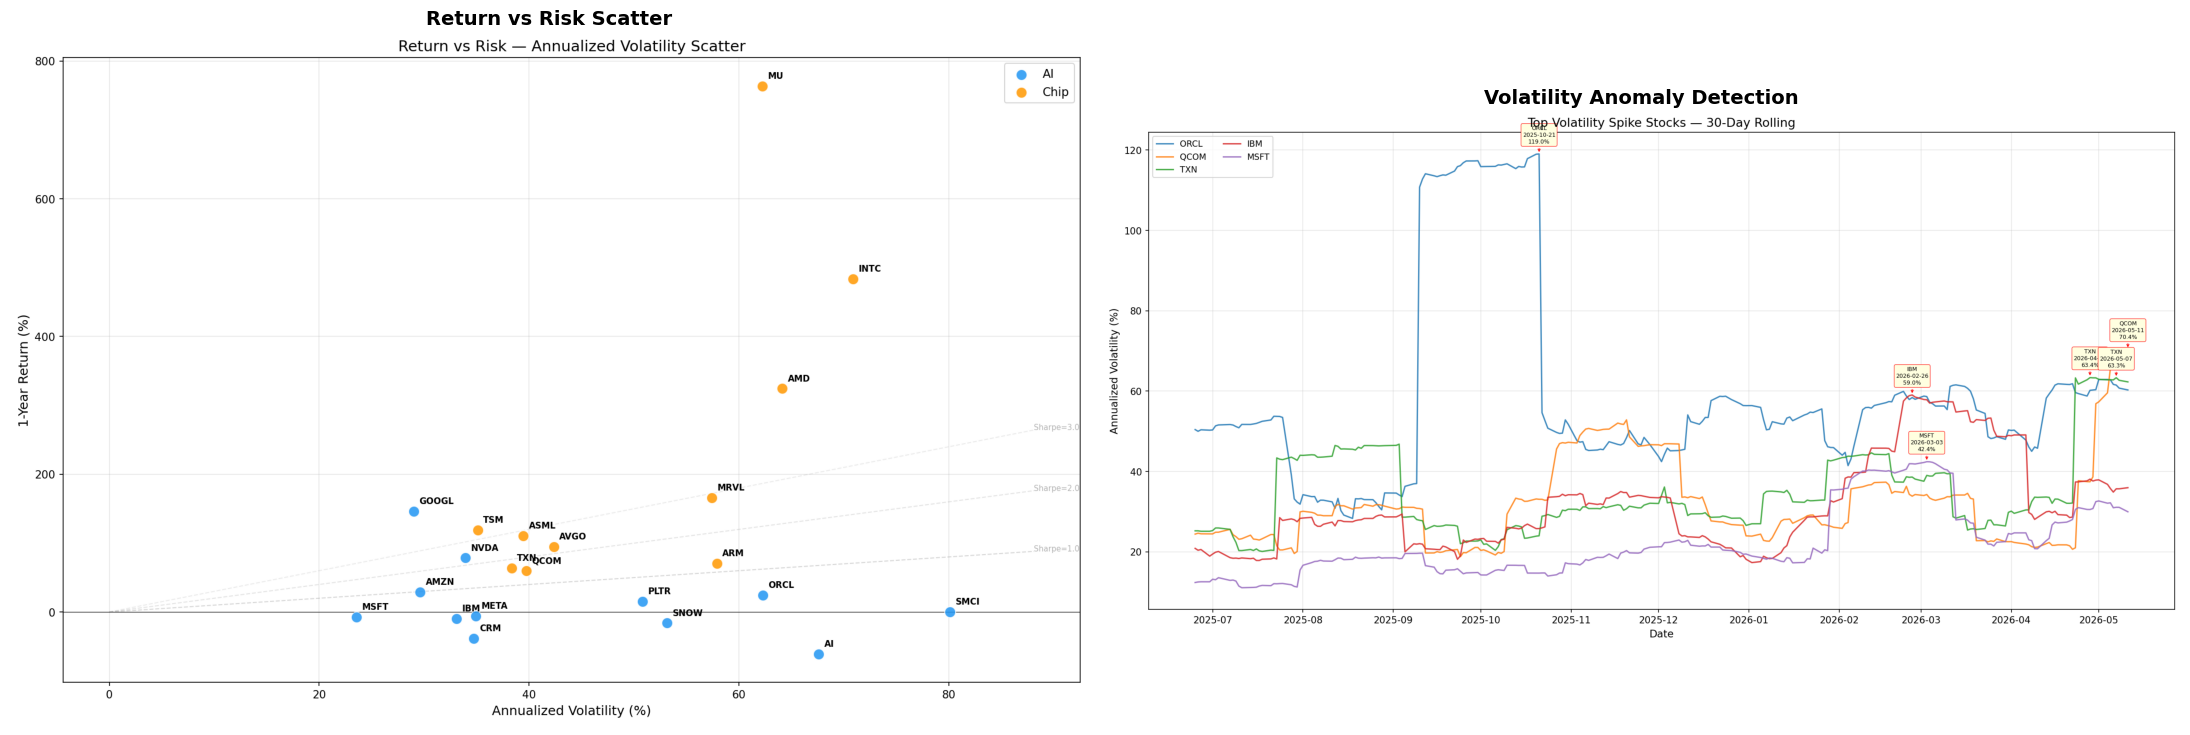

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
ax1.imshow(mpimg.imread(str(CHART / "Part2_Volatility/Step4_AnnualizedVol/return_vs_risk_scatter.png")))
ax1.set_title("Return vs Risk Scatter", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part2_Volatility/Step5_RollingVol/volatility_spike_highlight.png")))
ax2.set_title("Volatility Anomaly Detection", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

**Major volatility events:**

| Ticker | Period | Peak Volatility | Catalyst |
|---|---|:---:|---|
| ORCL | Sep–Oct 2025 | 119.0% | \$300B OpenAI cloud deal surge followed by earnings miss |
| QCOM | May 2026 | 70.4% | Earnings beat + US-China tariff pause + AI phone chip news |
| IBM | Feb–Mar 2026 | 59.0% | Single-day -13.15%, Anthropic COBOL disruption narrative |
| MSFT | Feb–Mar 2026 | 42.4% | Worst quarter since 2008, \$357B market cap erased in a day |

---
## Part 3: Correlation Analysis

### Step 6 — AI & Chip Correlation

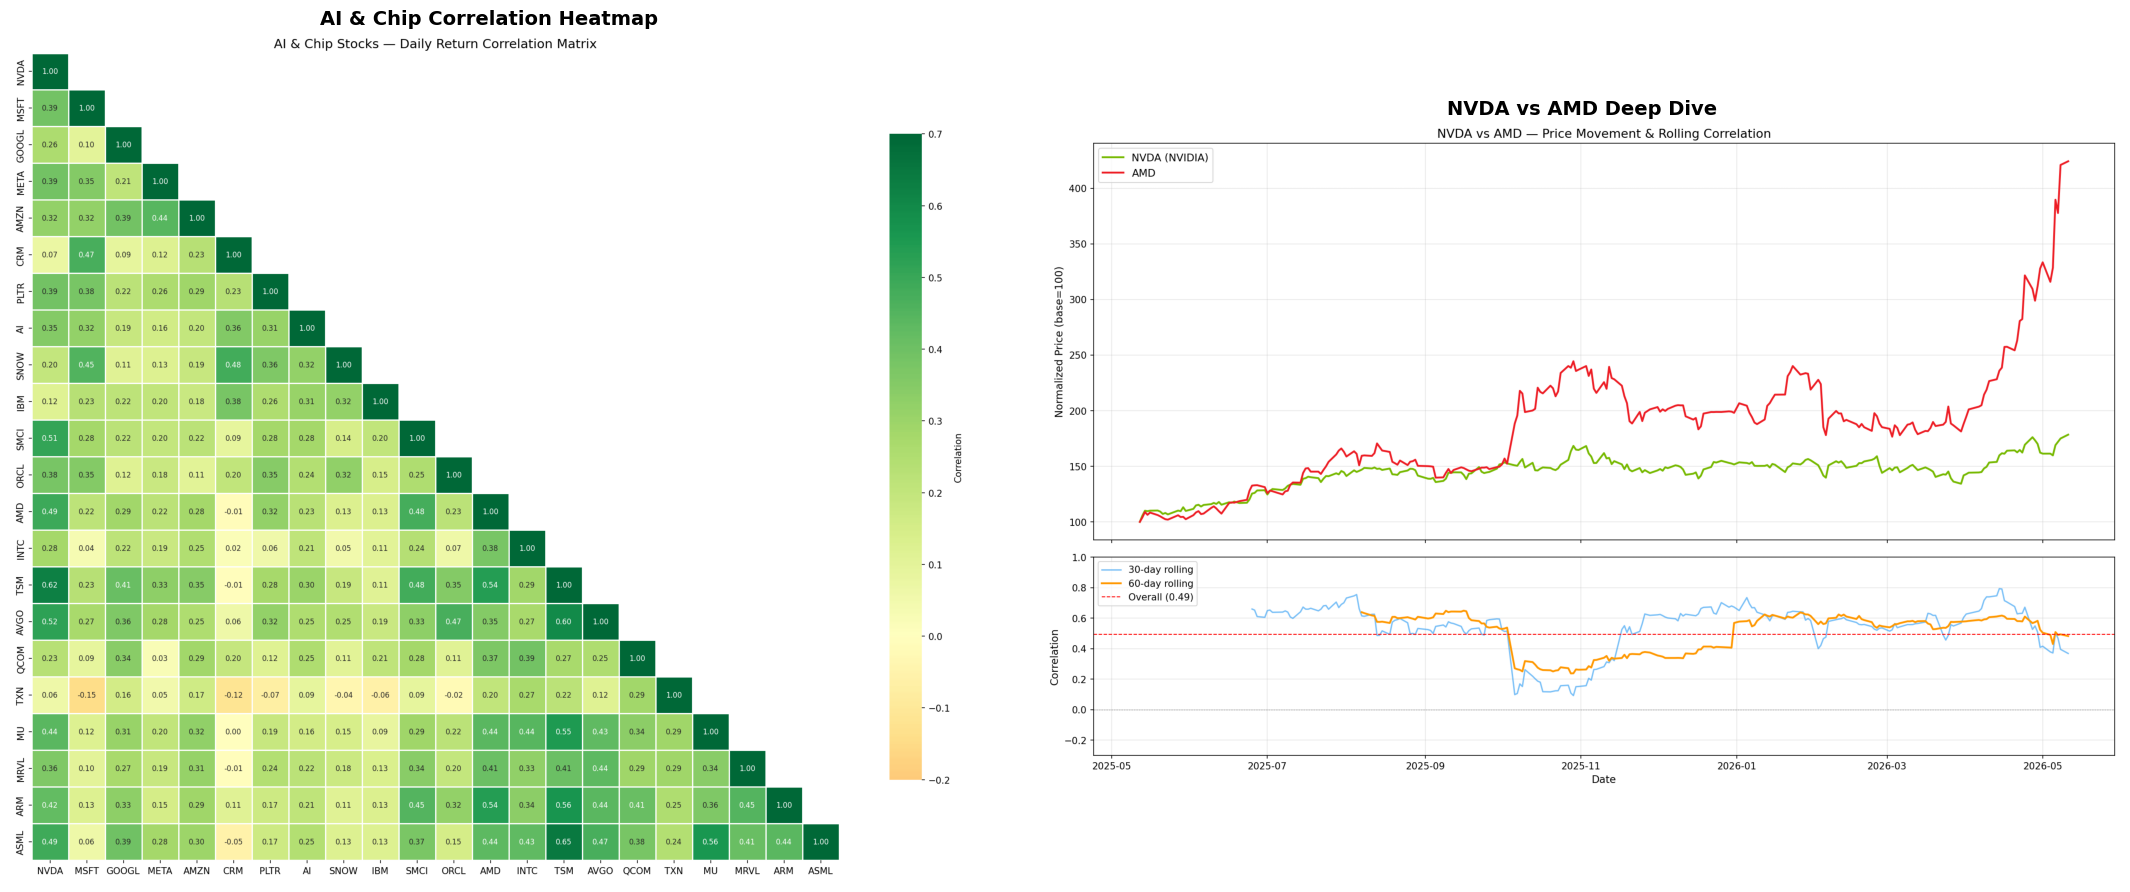

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 9))
ax1.imshow(mpimg.imread(str(CHART / "Part3_Correlation/Step6_AIChipCorrelation/correlation_heatmap_ai_chip.png")))
ax1.set_title("AI & Chip Correlation Heatmap", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part3_Correlation/Step6_AIChipCorrelation/nvda_vs_amd.png")))
ax2.set_title("NVDA vs AMD Deep Dive", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

**Key findings:**
- **TSM is the correlation hub**, with 7 stocks correlated > 0.45 (ASML 0.65, NVDA 0.62, AVGO 0.60)
- **NVDA vs AMD:** Correlation 0.49, same-direction days 68.4% — competitors but not interchangeable
- **TXN is the outlier:** Negatively correlated with several AI stocks, independent of the tech/AI ecosystem

### Step 7 — Beta Analysis (vs S&P 500)

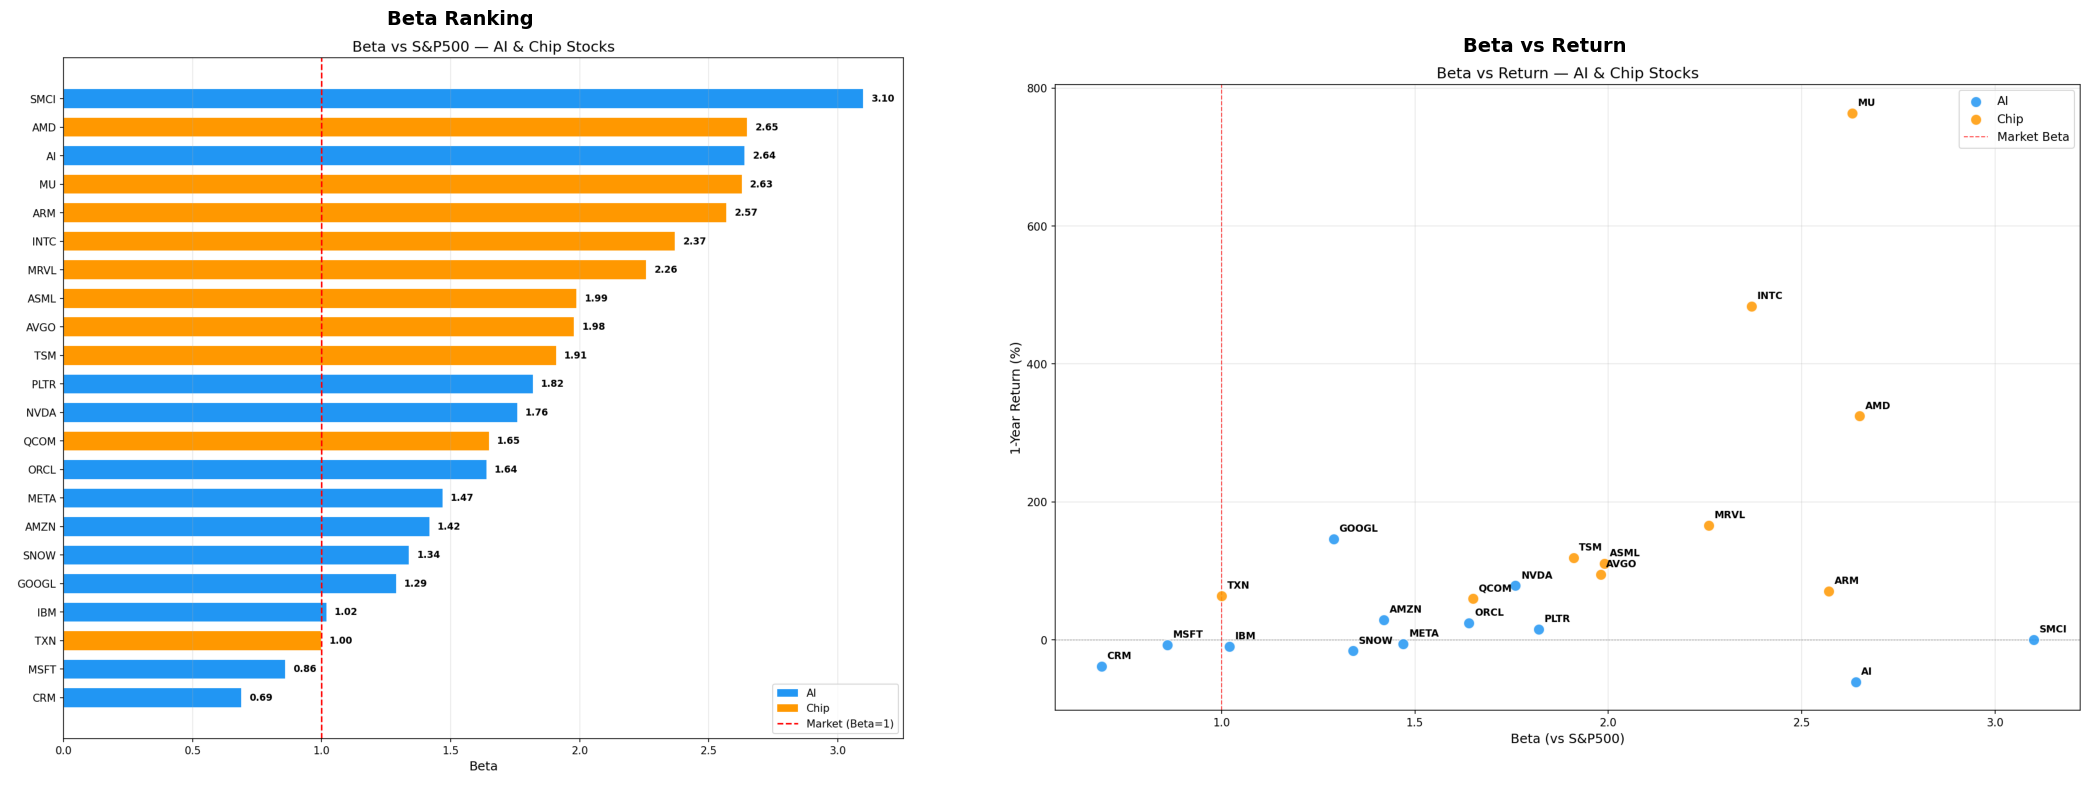

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
ax1.imshow(mpimg.imread(str(CHART / "Part3_Correlation/Step7_Beta/beta_ranking.png")))
ax1.set_title("Beta Ranking", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part3_Correlation/Step7_Beta/beta_vs_return.png")))
ax2.set_title("Beta vs Return", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

**High Beta ≠ High Return:** SMCI (Beta 3.10) returned 0%, while GOOGL (Beta 1.29) returned +146%. Seek positive Alpha, not just high Beta.

---
## Part 4: Lead-Lag Analysis

### Step 8 — Lagged Correlation & Step 9 — Leadership Scores

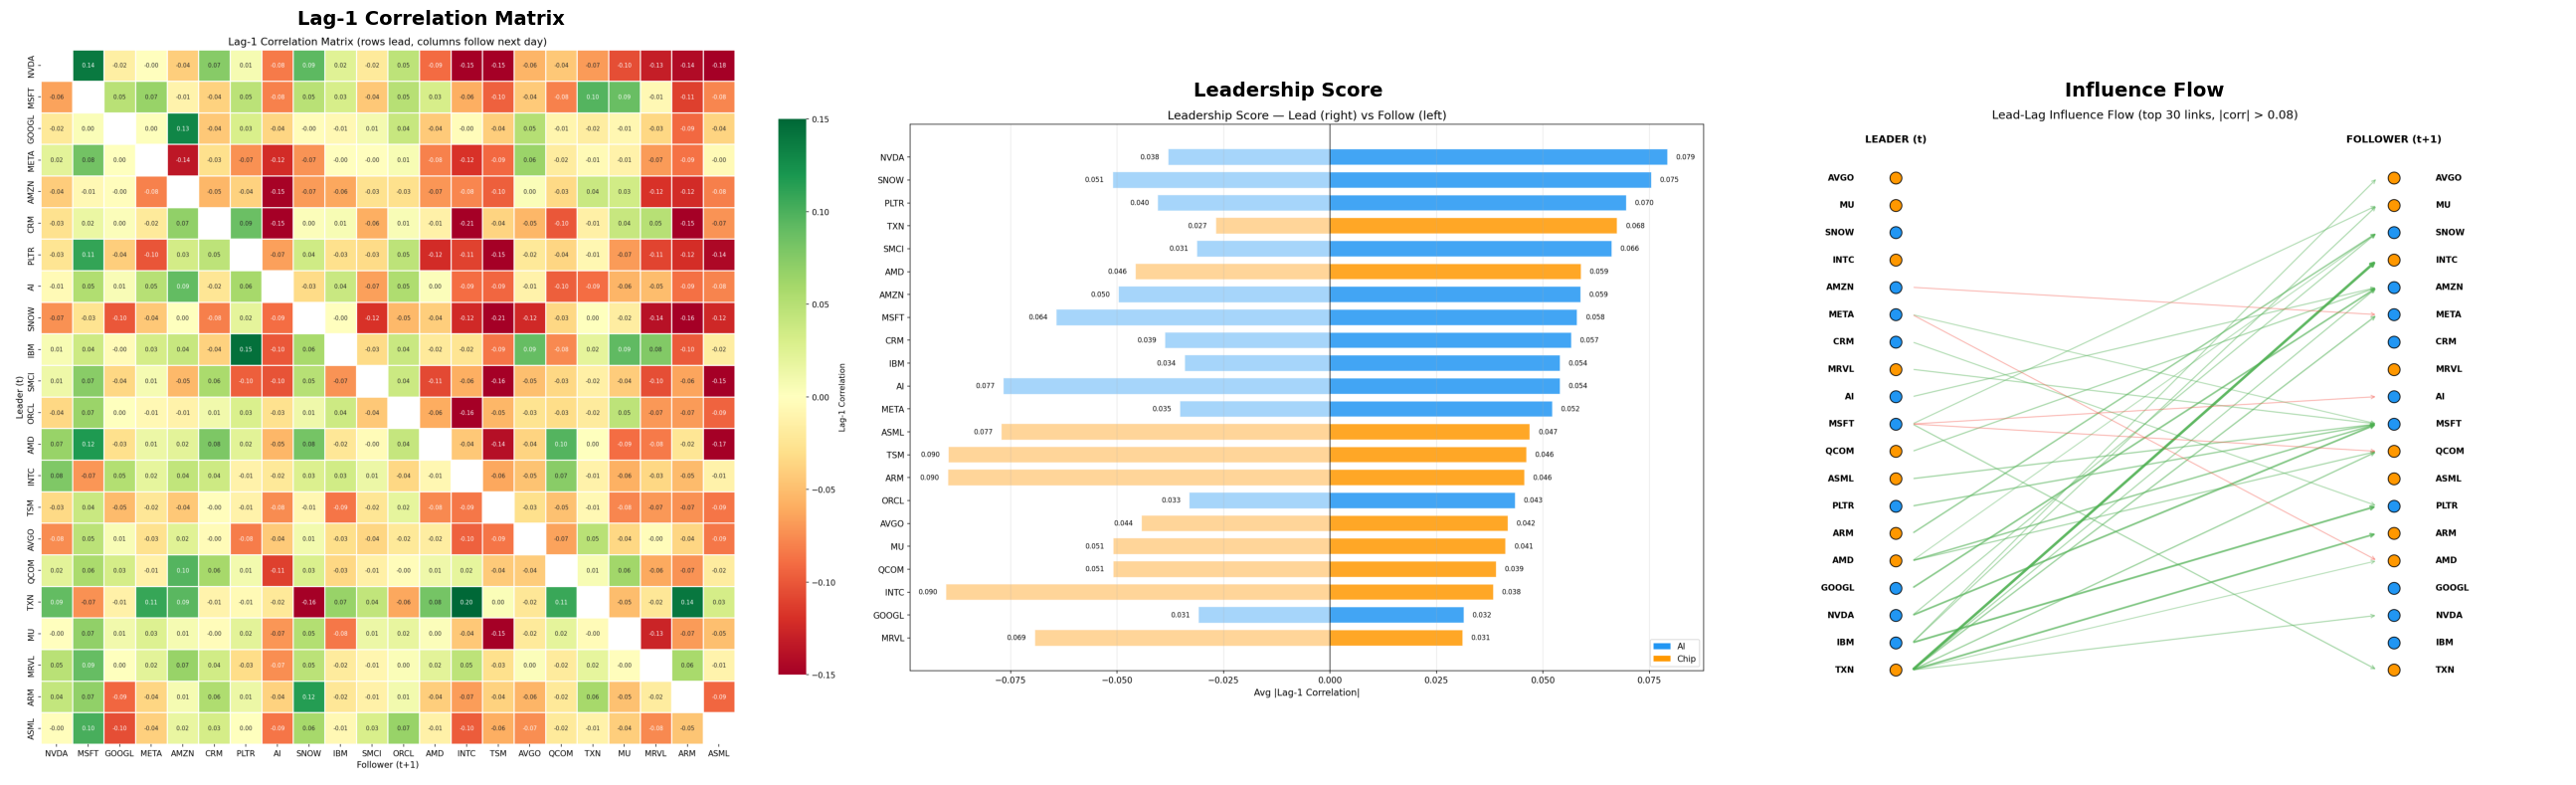

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(26, 8))
imgs = [
    (CHART / "Part4_LeadLag/Step8_LaggedCorrelation/lag1_heatmap.png", "Lag-1 Correlation Matrix"),
    (CHART / "Part4_LeadLag/Step9_Leadership/leadership_score.png", "Leadership Score"),
    (CHART / "Part4_LeadLag/Step9_Leadership/influence_flow.png", "Influence Flow"),
]
for ax, (path, title) in zip(axes, imgs):
    ax.imshow(mpimg.imread(str(path)))
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [11]:
scores = pd.read_csv(CHART / "Part4_LeadLag/Step9_Leadership/leadership_scores.csv")
leaders = scores[scores["Lead_Ratio"] > 1.2].sort_values("Lead_Ratio", ascending=False)
followers = scores[scores["Lead_Ratio"] < 0.8].sort_values("Lead_Ratio")

print("Pure Leaders (Lead_Ratio > 1.2)")
display(leaders[["Ticker", "Name", "Sector", "Avg_Lead_Corr", "Lead_Ratio", "Strongest_Leads", "Lead_Corr"]])
print("\nPure Followers (Lead_Ratio < 0.8)")
display(followers[["Ticker", "Name", "Sector", "Avg_Follow_Corr", "Lead_Ratio", "Strongest_Follows", "Follow_Corr"]])

Pure Leaders (Lead_Ratio > 1.2)


,Ticker,Name,Sector,Avg_Lead_Corr,Lead_Ratio,Strongest_Leads,Lead_Corr
17,TXN,Texas Instruments,Chip,0.0675,2.52,INTC,0.2028
10,SMCI,Super Micro Computer,AI,0.0662,2.12,TSM,-0.1610
0,NVDA,NVIDIA,AI,0.0793,2.09,ASML,-0.1788
6,PLTR,Palantir,AI,0.0696,1.73,TSM,-0.1546
9,IBM,IBM,AI,0.0541,1.59,PLTR,0.1451
3,META,Meta,AI,0.0523,1.49,AMZN,-0.1350
8,SNOW,Snowflake,AI,0.0755,1.48,TSM,-0.2053
5,CRM,Salesforce,AI,0.0567,1.47,INTC,-0.2068
11,ORCL,Oracle,AI,0.0435,1.32,INTC,-0.1626
12,AMD,AMD,Chip,0.0590,1.29,ASML,-0.1653



Pure Followers (Lead_Ratio < 0.8)


,Ticker,Name,Sector,Avg_Follow_Corr,Lead_Ratio,Strongest_Follows,Follow_Corr
13,INTC,Intel,Chip,0.0901,0.43,CRM,-0.2068
19,MRVL,Marvell,Chip,0.0693,0.45,SNOW,-0.1388
20,ARM,Arm Holdings,Chip,0.0897,0.51,SNOW,-0.1647
14,TSM,TSMC,Chip,0.0896,0.52,SNOW,-0.2053
21,ASML,ASML,Chip,0.0771,0.61,NVDA,-0.1788
7,AI,C3.ai,AI,0.0767,0.71,CRM,-0.1542
16,QCOM,Qualcomm,Chip,0.0509,0.77,TXN,0.1067


**Information flow hierarchy:**

```
Signal sources: TXN(2.52), NVDA(2.09), SMCI(2.12), PLTR(1.73)  ← Leaders
    │
    │  1–2 day lag
    ▼
Signal receivers: INTC(0.43), MRVL(0.45), ARM(0.51), TSM(0.52)  ← Followers
```

Influence flows from AI/platform companies downstream to chip suppliers, consistent with real-world semiconductor supply chain hierarchy.

---
## Part 5: Risk Analysis

### Step 10 — Drawdown Analysis

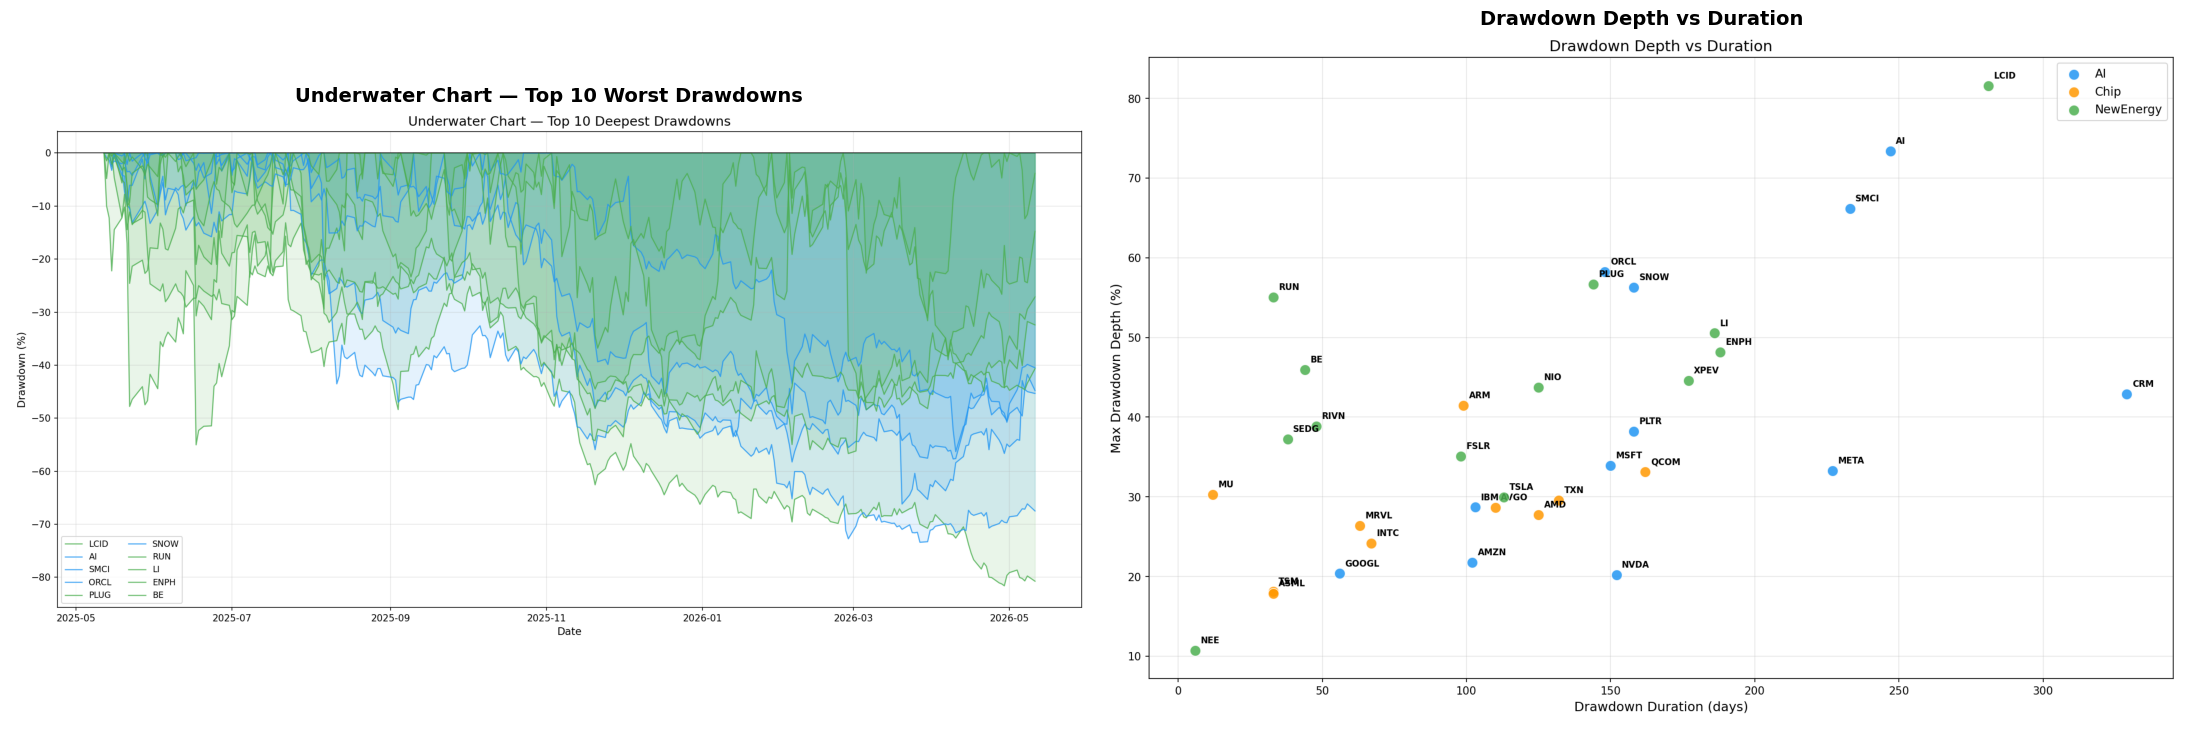

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
ax1.imshow(mpimg.imread(str(CHART / "Part5_Risk/Step10_Drawdown/underwater_top10.png")))
ax1.set_title("Underwater Chart — Top 10 Worst Drawdowns", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part5_Risk/Step10_Drawdown/drawdown_depth_vs_duration.png")))
ax2.set_title("Drawdown Depth vs Duration", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

In [13]:
dd = pd.read_csv(CHART / "Part5_Risk/Step10_Drawdown/drawdown_analysis.csv")
print("Top 10 Worst Drawdowns (by severity)")
display(dd.nsmallest(10, "Max_Drawdown%")[
    ["Ticker", "Name", "Sector", "Max_Drawdown%", "Peak_Date", "Trough_Date", "Drawdown_Days", "Recovery_Date"]
].reset_index(drop=True))

Top 10 Worst Drawdowns (by severity)


,Ticker,Name,Sector,Max_Drawdown%,Peak_Date,Trough_Date,Drawdown_Days,Recovery_Date
0,LCID,Lucid,NewEnergy,-81.60,2025-07-22,2026-04-29,281,Not recovered
1,AI,C3.ai,AI,-73.39,2025-07-23,2026-03-27,247,Not recovered
2,SMCI,Super Micro Computer,AI,-66.18,2025-07-30,2026-03-20,233,Not recovered
3,ORCL,Oracle,AI,-58.25,2025-09-10,2026-02-05,148,Not recovered
4,PLUG,Plug Power,NewEnergy,-56.66,2025-10-06,2026-02-27,144,Not recovered
5,SNOW,Snowflake,AI,-56.30,2025-11-03,2026-04-10,158,Not recovered
6,RUN,Sunrun,NewEnergy,-55.02,2025-05-15,2025-06-17,33,2025-08-15
7,LI,Li Auto,NewEnergy,-50.53,2025-07-18,2026-01-20,186,Not recovered
8,ENPH,Enphase Energy,NewEnergy,-48.17,2025-05-16,2025-11-20,188,2026-02-04
9,BE,Bloom Energy,NewEnergy,-45.94,2025-11-03,2025-12-17,44,2026-01-16


### Step 11 — Risk Metrics (VaR, Sharpe, Sortino, Calmar)

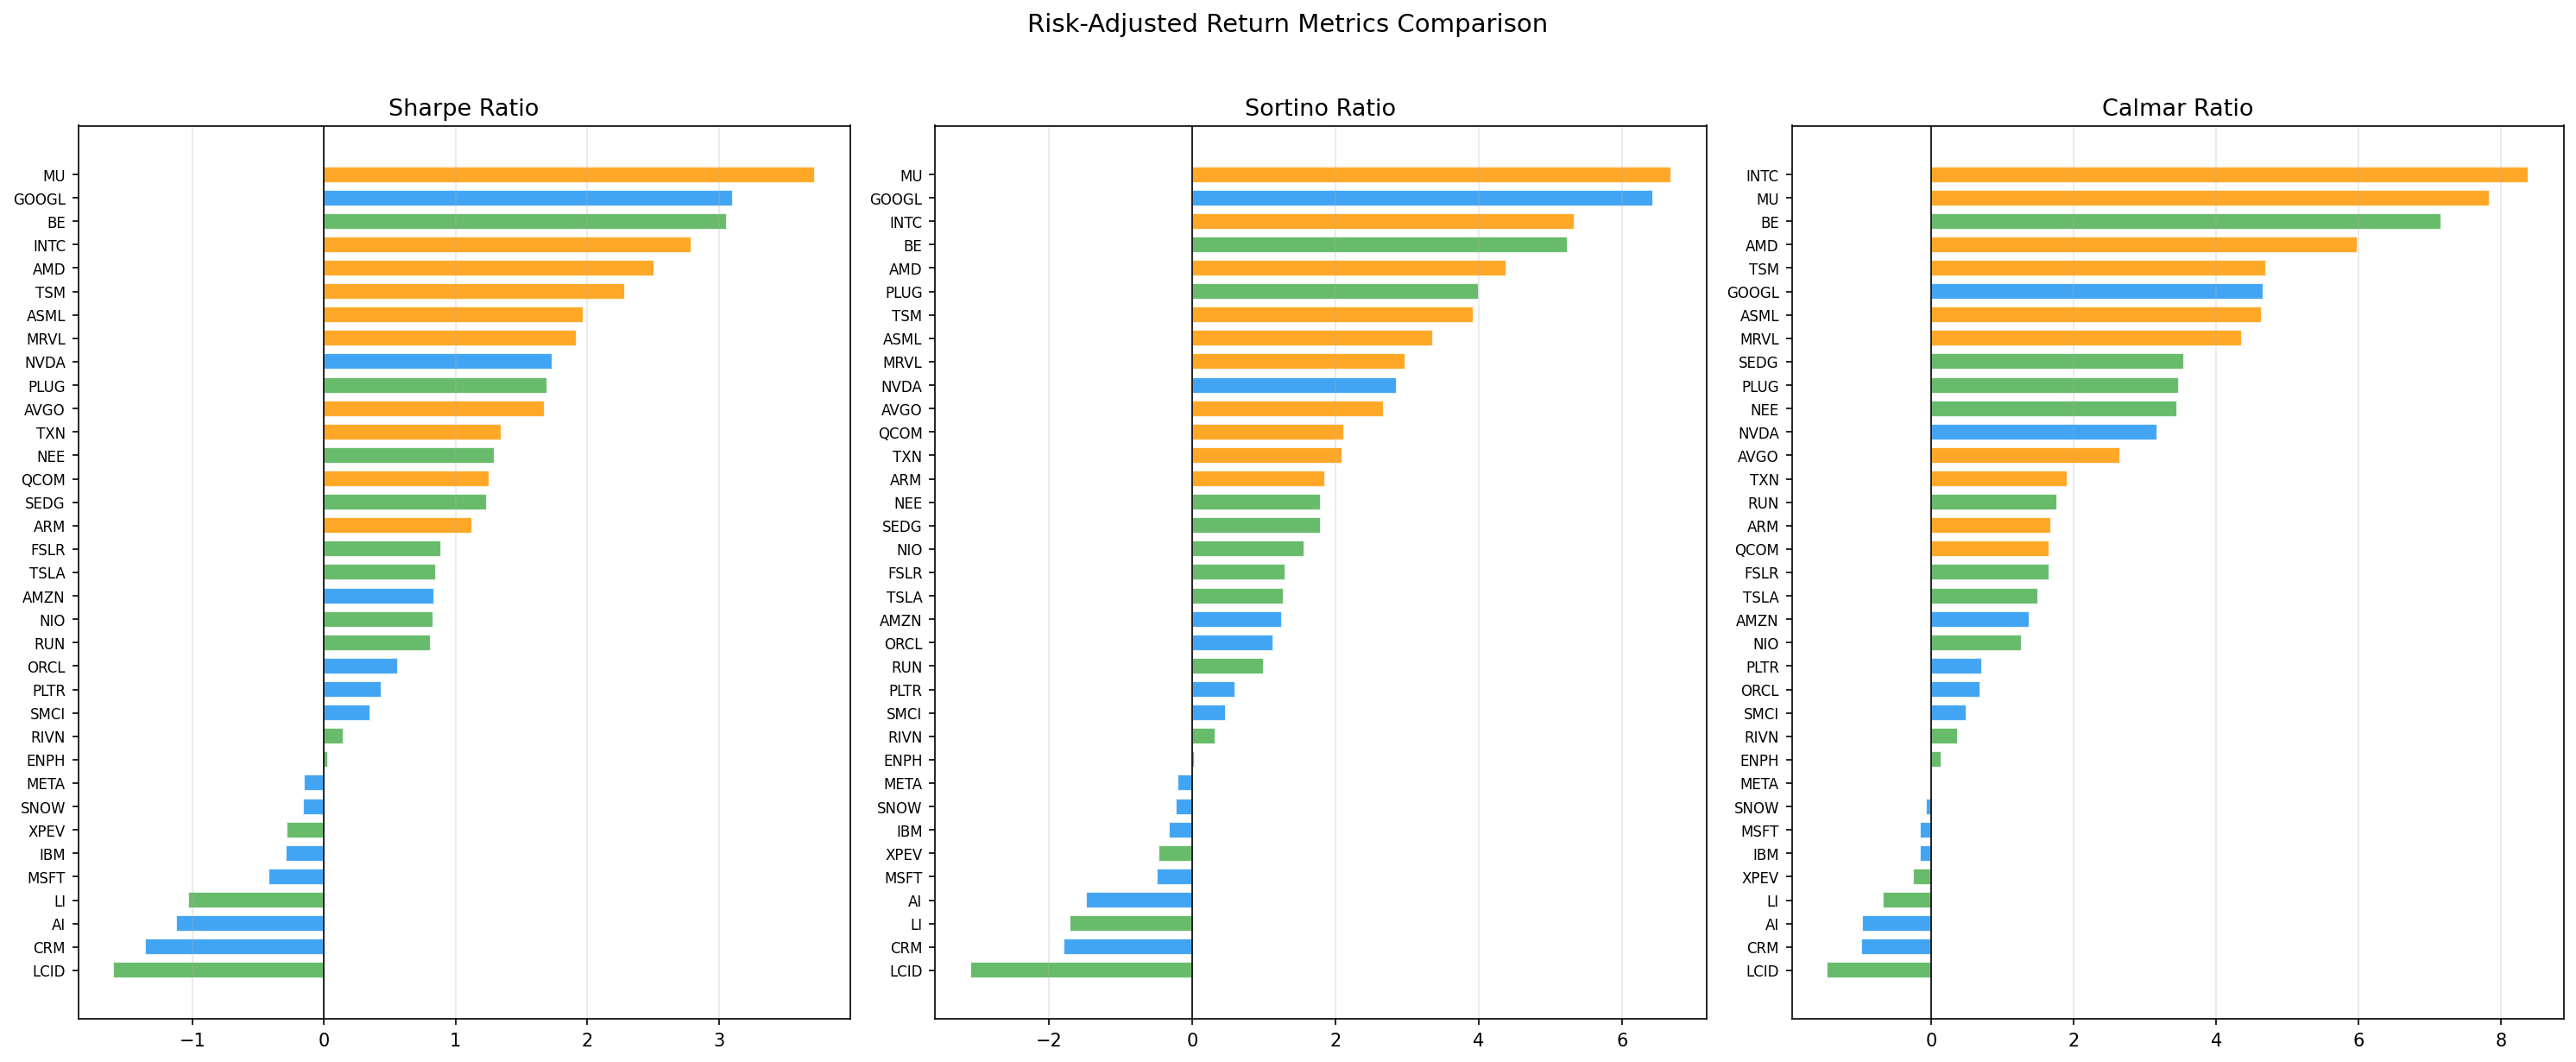

In [14]:
display(Image(str(CHART / "Part5_Risk/Step11_RiskMetrics/risk_ratios_comparison.png"), width=950))

In [15]:
risk = pd.read_csv(CHART / "Part5_Risk/Step11_RiskMetrics/risk_metrics.csv")

print("Sector Risk Summary")
sector_risk = risk.groupby("Sector").agg({
    "Ann_Return%": "mean", "Ann_Vol%": "mean", "Sharpe": "mean",
    "Sortino": "mean", "Max_DD%": "mean", "VaR_95_Hist%": "mean", "Beta": "mean",
}).round(2)
display(sector_risk.sort_values("Sharpe", ascending=False))

print("\nTop 10 by Sharpe Ratio")
display(risk.nlargest(10, "Sharpe")[
    ["Ticker", "Name", "Sector", "Ann_Return%", "Ann_Vol%", "Sharpe", "Sortino", "Calmar", "Beta"]
].reset_index(drop=True))

Sector Risk Summary


,Ann_Return%,Ann_Vol%,Sharpe,Sortino,Max_DD%,VaR_95_Hist%,Beta
Sector,,,,,,,
Chip,114.70,50.75,2.06,3.54,-27.74,-3.93,2.10
NewEnergy,62.24,72.56,0.61,1.00,-44.47,-6.06,1.83
AI,13.60,44.40,0.30,0.68,-41.12,-4.02,1.59



Top 10 by Sharpe Ratio


,Ticker,Name,Sector,Ann_Return%,Ann_Vol%,Sharpe,Sortino,Calmar,Beta
0,MU,Micron,Chip,237.31,62.22,3.73,6.69,7.84,2.63
1,GOOGL,Google,AI,95.06,29.00,3.11,6.43,4.67,1.29
2,BE,Bloom Energy,NewEnergy,328.87,105.89,3.06,5.24,7.16,3.74
3,INTC,Intel,Chip,202.59,70.88,2.79,5.34,8.38,2.37
4,AMD,AMD,Chip,166.01,64.11,2.51,4.38,5.98,2.65
5,TSM,TSMC,Chip,85.26,35.10,2.29,3.93,4.70,1.91
6,ASML,ASML,Chip,82.78,39.45,1.97,3.36,4.64,1.99
7,MRVL,Marvell,Chip,115.00,57.40,1.92,2.98,4.36,2.26
8,NVDA,NVIDIA,AI,64.15,33.92,1.74,2.85,3.17,1.76
9,PLUG,Plug Power,NewEnergy,197.19,112.81,1.70,4.00,3.48,2.67


**Chip sector leads on every risk-adjusted metric.** NewEnergy has the worst daily VaR (-6.1%); the highest tail-risk stocks are all NewEnergy (RUN -25.8%, ENPH -14.7%).

---
## Part 6: Portfolio Optimization

### Step 12 — Efficient Frontier

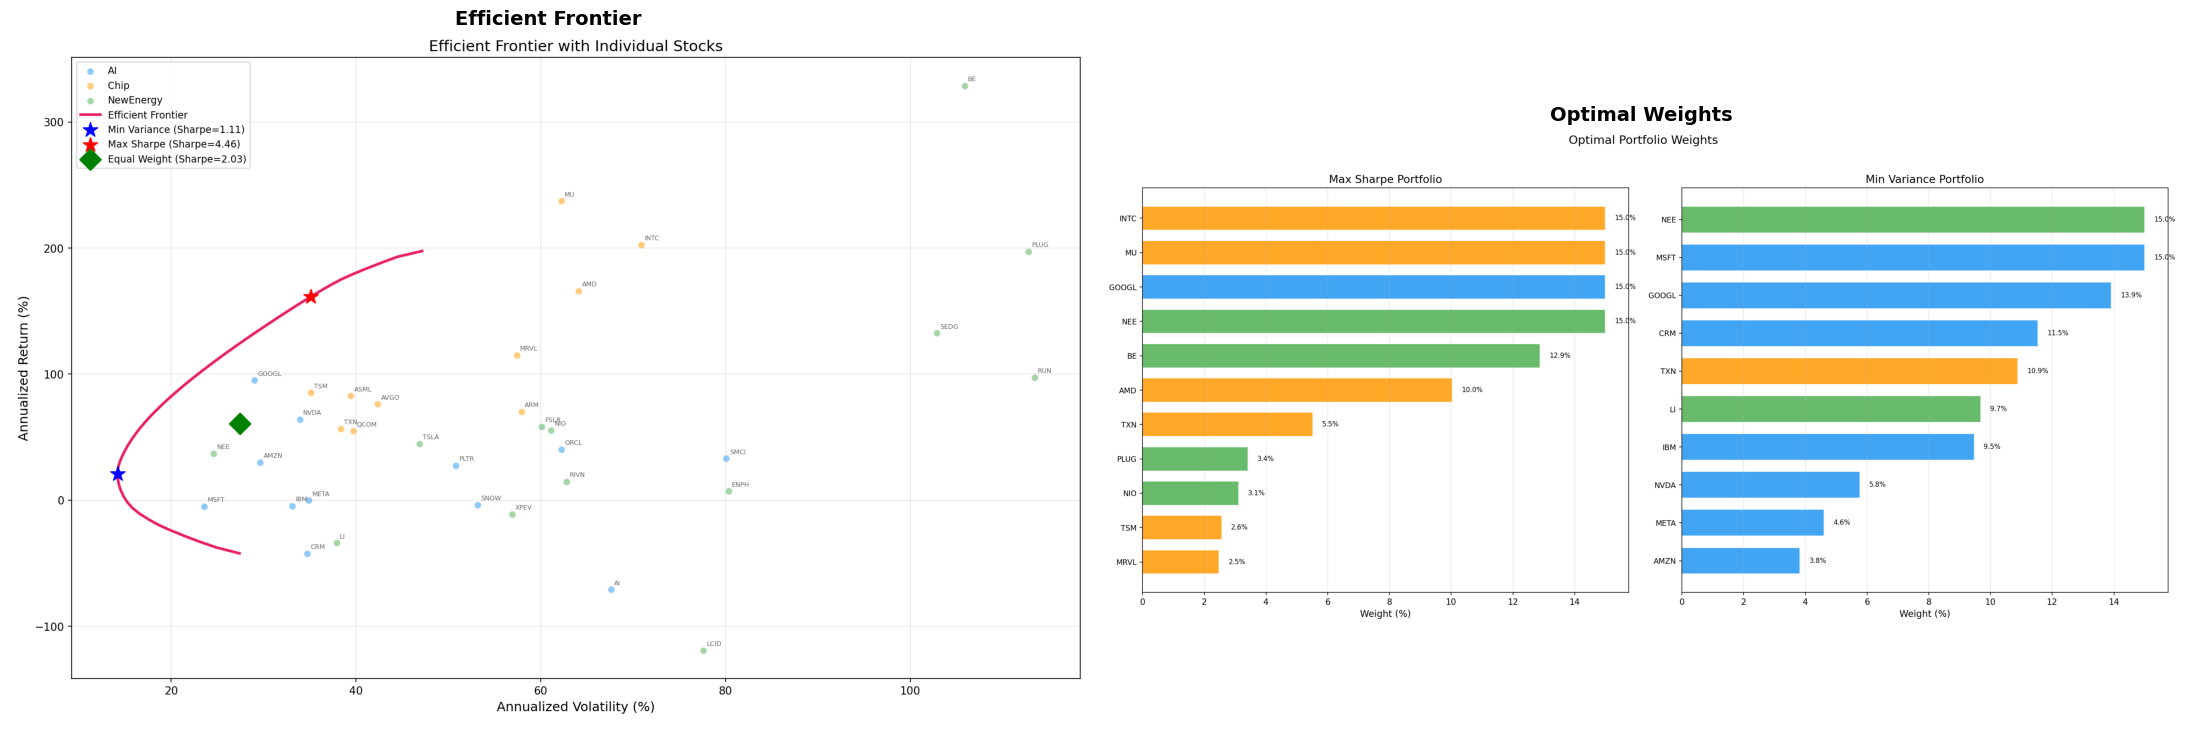

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(22, 8))
ax1.imshow(mpimg.imread(str(CHART / "Part6_Portfolio/Step12_EfficientFrontier/efficient_frontier.png")))
ax1.set_title("Efficient Frontier", fontsize=14, fontweight="bold")
ax1.axis("off")
ax2.imshow(mpimg.imread(str(CHART / "Part6_Portfolio/Step12_EfficientFrontier/optimal_weights.png")))
ax2.set_title("Optimal Weights", fontsize=14, fontweight="bold")
ax2.axis("off")
plt.tight_layout()
plt.show()

In [17]:
weights = pd.read_csv(CHART / "Part6_Portfolio/Step12_EfficientFrontier/optimal_weights.csv")

print("Max Sharpe Portfolio — Core Holdings (weight > 1%)")
ms = weights[weights["MaxSharpe_Weight%"] > 1].sort_values("MaxSharpe_Weight%", ascending=False)
display(ms[["Ticker", "Name", "Sector", "MaxSharpe_Weight%"]].reset_index(drop=True))

print("\nMin Variance Portfolio — Core Holdings (weight > 1%)")
mv = weights[weights["MinVar_Weight%"] > 1].sort_values("MinVar_Weight%", ascending=False)
display(mv[["Ticker", "Name", "Sector", "MinVar_Weight%"]].reset_index(drop=True))

print("\nSector Allocation Comparison")
alloc = []
for label, col in [("Max Sharpe", "MaxSharpe_Weight%"), ("Min Variance", "MinVar_Weight%"), ("Equal Weight", "EqualWeight%")]:
    row = {"Portfolio": label}
    for sector in ["AI", "Chip", "NewEnergy"]:
        pct = weights[weights["Sector"] == sector][col].sum()
        row[sector] = f"{pct:.1f}%"
    alloc.append(row)
display(pd.DataFrame(alloc).set_index("Portfolio"))

Max Sharpe Portfolio — Core Holdings (weight > 1%)


,Ticker,Name,Sector,MaxSharpe_Weight%
0,GOOGL,Google,AI,15.00
1,INTC,Intel,Chip,15.00
2,MU,Micron,Chip,15.00
3,NEE,NextEra Energy,NewEnergy,15.00
4,BE,Bloom Energy,NewEnergy,12.88
5,AMD,AMD,Chip,10.03
6,TXN,Texas Instruments,Chip,5.51
7,PLUG,Plug Power,NewEnergy,3.41
8,NIO,NIO,NewEnergy,3.12
9,TSM,TSMC,Chip,2.56



Min Variance Portfolio — Core Holdings (weight > 1%)


,Ticker,Name,Sector,MinVar_Weight%
0,MSFT,Microsoft,AI,15.00
1,NEE,NextEra Energy,NewEnergy,15.00
2,GOOGL,Google,AI,13.91
3,CRM,Salesforce,AI,11.54
4,TXN,Texas Instruments,Chip,10.88
5,LI,Li Auto,NewEnergy,9.69
6,IBM,IBM,AI,9.48
7,NVDA,NVIDIA,AI,5.77
8,META,Meta,AI,4.60
9,AMZN,Amazon,AI,3.83



Sector Allocation Comparison


,AI,Chip,NewEnergy
Portfolio,,,
Max Sharpe,15.0%,50.6%,34.4%
Min Variance,64.1%,11.2%,24.7%
Equal Weight,34.3%,28.6%,37.2%


### Step 13 — Portfolio Backtesting

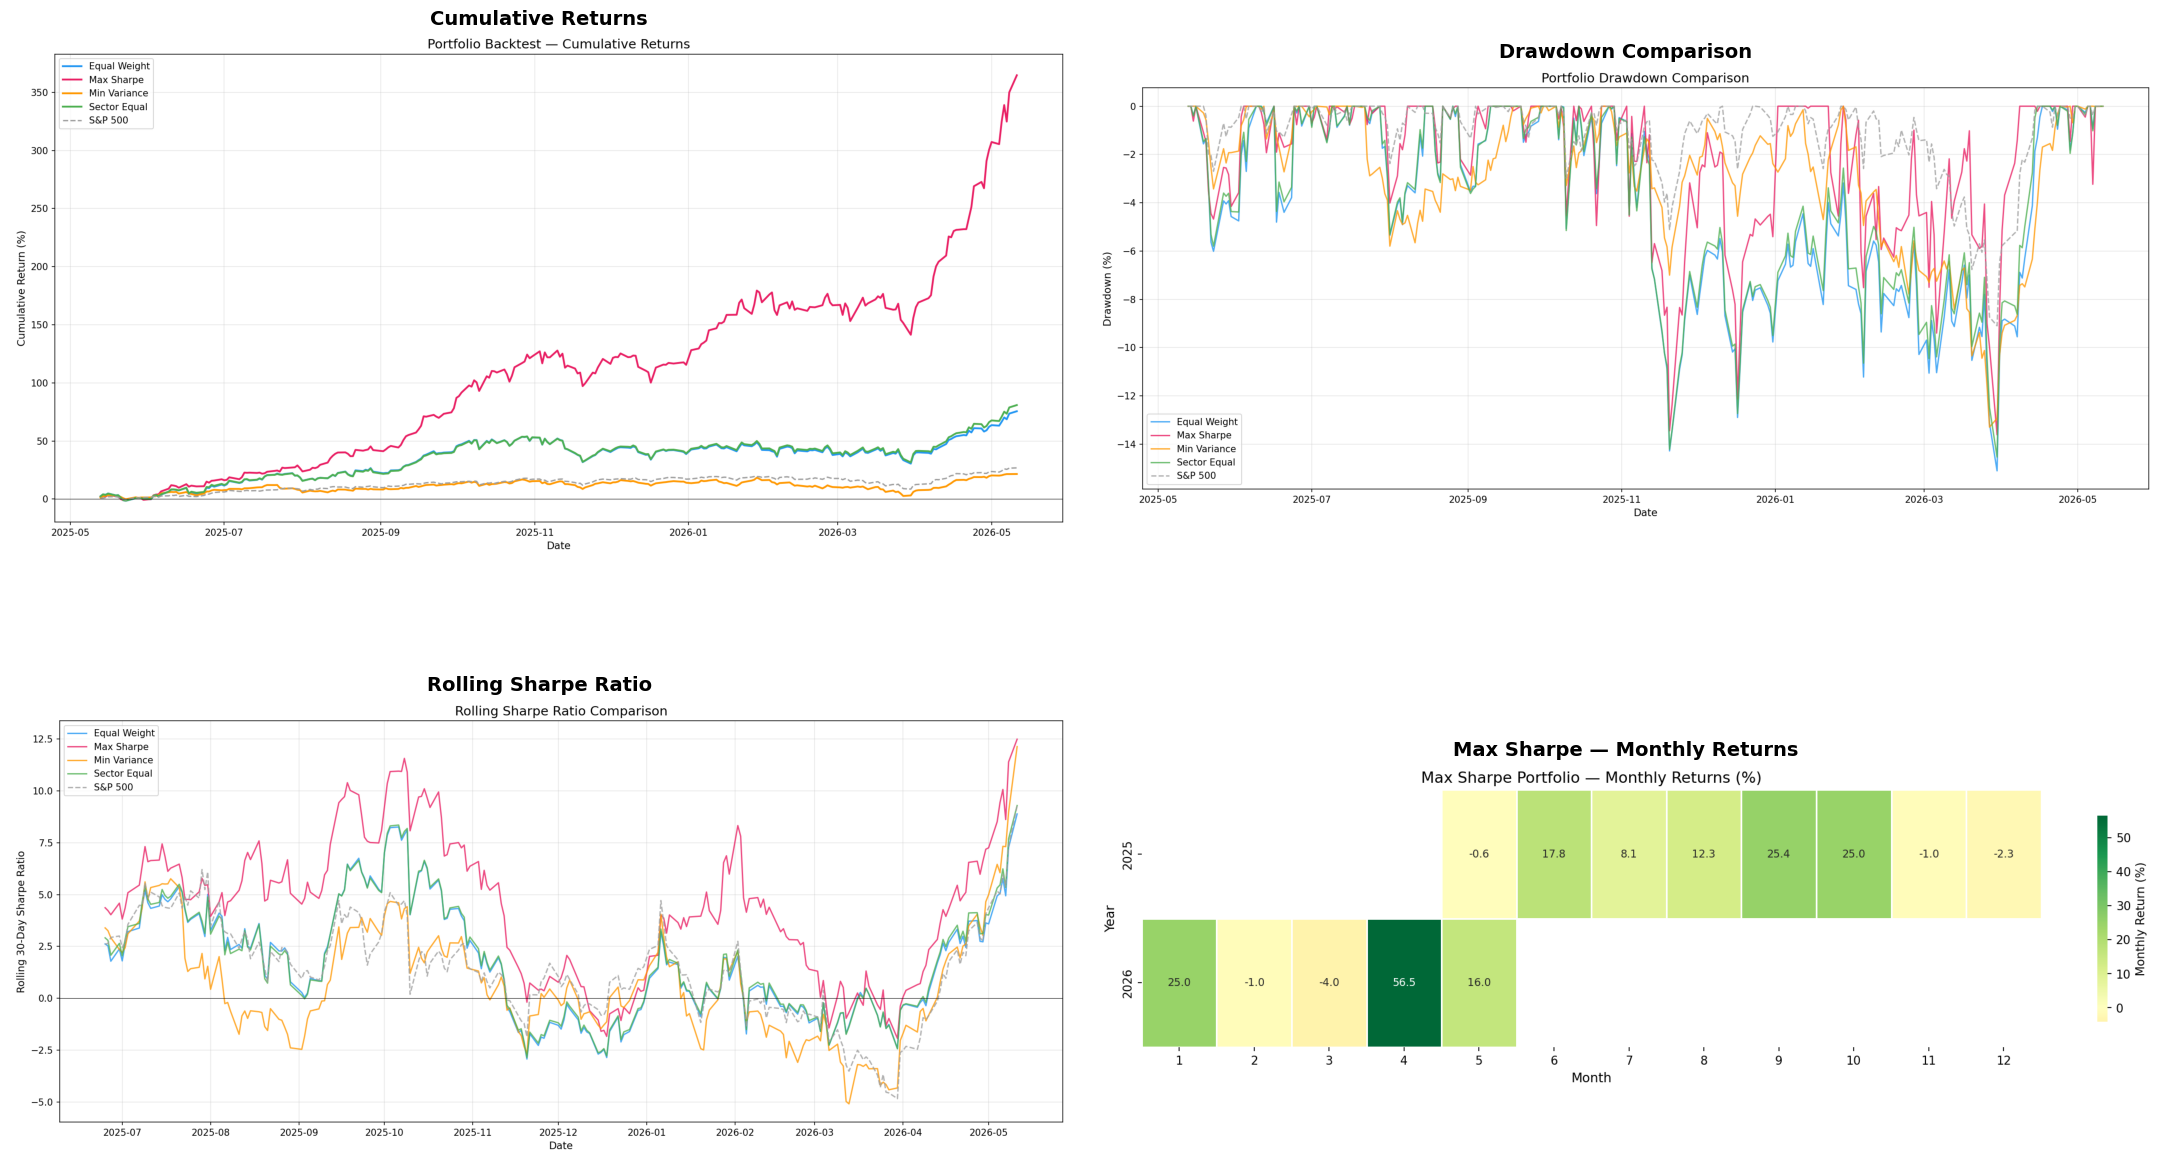

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(22, 14))
imgs = [
    (CHART / "Part6_Portfolio/Step13_Backtest/cumulative_returns.png", "Cumulative Returns"),
    (CHART / "Part6_Portfolio/Step13_Backtest/drawdown_comparison.png", "Drawdown Comparison"),
    (CHART / "Part6_Portfolio/Step13_Backtest/rolling_sharpe.png", "Rolling Sharpe Ratio"),
    (CHART / "Part6_Portfolio/Step13_Backtest/monthly_returns_heatmap.png", "Max Sharpe — Monthly Returns"),
]
for ax, (path, title) in zip(axes.flat, imgs):
    ax.imshow(mpimg.imread(str(path)))
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")
plt.tight_layout(pad=2)
plt.show()

In [19]:
print("Portfolio Performance Comparison")
portfolio_perf = pd.read_csv(CHART / "Part6_Portfolio/Step13_Backtest/portfolio_performance.csv")
display(portfolio_perf.set_index("Portfolio"))

Portfolio Performance Comparison


,Total_Return%,Ann_Return%,Ann_Vol%,Sharpe,Sortino,Max_DD%,Calmar,Win_Rate%
Portfolio,,,,,,,,
Equal Weight,75.59,60.55,27.42,2.03,3.14,-15.11,4.01,56.4
Max Sharpe,364.75,161.45,35.10,4.46,6.82,-13.61,11.86,63.6
Min Variance,21.56,20.69,14.18,1.11,1.69,-13.29,1.56,58.0
Sector Equal,80.90,63.51,27.24,2.15,3.34,-14.54,4.37,56.0
S&P 500,26.84,24.71,12.09,1.63,2.34,-9.10,2.72,57.2


> **Note:** This is a static-weight, no-rebalancing, in-sample backtest. Real-world performance would be lower due to transaction costs, slippage, and the inability to know optimal weights in advance.

---
## Conclusion

### Five Key Findings

**1. Silicon beats software.**
The Chip sector (+225.5%) massively outperformed AI software (+13.0%). The market rewarded companies physically building AI infrastructure over those trying to sell AI features.

**2. Information flows follow the supply chain.**
Demand signals propagate from AI compute buyers (NVDA, PLTR, SMCI) to semiconductor manufacturers (TSM, INTC, ASML) with a 1–2 day lag.

**3. New Energy is a diversifier, not a co-mover.**
Cross-sector stock-level correlation is below 0.18. Intra-sector dispersion is extreme (BE +1401% vs LCID -77%).

**4. High Beta ≠ High Return.**
SMCI (Beta 3.10) returned 0%, while GOOGL (Beta 1.29) returned +146%. The best risk-adjusted returns come from moderate Beta + strong fundamentals.

**5. Portfolio optimization works.**
The mean-variance Max Sharpe portfolio outperformed equal weight by 4.7x (+364.8% vs +75.6%), proving that systematic weight allocation can meaningfully improve returns even in a simple long-only framework.

### Portfolio Implications

| Category | Tickers | Rationale |
|---|---|---|
| **Core Holdings** | GOOGL, TSM, ASML | Best risk-adjusted returns (Sharpe 2.1–3.3), moderate volatility |
| **Growth Allocation** | MU, AMD, INTC | Highest absolute returns, riding the chip super-cycle |
| **Diversifiers** | TXN, AMZN | Low correlation with the cluster, positive returns |
| **Avoid** | CRM, C3.ai, LCID, SNOW | Negative returns, high volatility |

> **Bottom line:** This was a year for silicon, not software. Until the market sees AI software generating revenue commensurate with its infrastructure costs, this dynamic is likely to persist.

---

### Methodology Notes

- **Risk-free rate:** 5% annualized (US Treasury proxy)
- **Portfolio constraints:** Long-only, max 15% per stock, fully invested
- **Optimization:** Mean-variance, `scipy.optimize` SLSQP solver
- **VaR:** Historical + parametric, 95% and 99% confidence levels
- **Backtest:** Static weights, no rebalancing, 1-year in-sample

*Tech stack: pandas / numpy / matplotlib / seaborn / scipy / yfinance*